# ASSISTments 2012-2013 Clustering — Final

In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


## Imports and configuration

In [2]:
from pathlib import Path
from itertools import combinations
import json
import warnings

import joblib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from scipy.stats import kruskal
from sklearn.cluster import KMeans, AgglomerativeClustering, DBSCAN
from sklearn.decomposition import PCA
from sklearn.ensemble import HistGradientBoostingRegressor
from sklearn.impute import SimpleImputer
from sklearn.inspection import permutation_importance
from sklearn.metrics import (
    adjusted_rand_score,
    calinski_harabasz_score,
    davies_bouldin_score,
    mean_absolute_error,
    normalized_mutual_info_score,
    silhouette_score,
)
from sklearn.mixture import GaussianMixture
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split
from sklearn.neighbors import NearestNeighbors
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler

warnings.filterwarnings('ignore', category=FutureWarning)
sns.set_theme(style='whitegrid')

RANDOM_STATE = 42
DATA_PATH = '/content/drive/MyDrive/datasets/2012-2013-data-with-predictions-4-final.csv'
OUTPUT_DIR = Path('/content/drive/MyDrive/datasets/assistments_final_outputs')
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

ROW_LIMIT = None
MIN_INTERACTIONS = 20
EARLY_FRACTION = 0.70
MIN_SKILL_LEARNERS = 100
MASTERY_PRIOR_STRENGTH = 5.0
PCA_VARIANCE = 0.95
K_VALUES = list(range(2, 10))
INTERPRET_K_VALUES = [5, 6]
STABILITY_REPEATS = 5
STABILITY_SAMPLE_FRACTION = 0.80
SILHOUETTE_SAMPLE_SIZE = 10_000
ALGORITHM_SAMPLE_SIZE = 5_000
ALGORITHM_REPEATS = 5
RUN_UMAP = False
RUN_SUPERVISED_IMPORTANCE = True

## Load the dataset

Timestamps are retained so that preprocessing and evaluation can respect event order.

In [3]:
usecols = [
    'problem_log_id', 'user_id', 'problem_id', 'assignment_id',
    'assistment_id', 'sequence_id', 'skill', 'skill_id',
    'start_time', 'end_time', 'correct', 'bottom_hint', 'hint_count',
    'attempt_count', 'ms_first_response', 'overlap_time', 'position',
    'first_action', 'Average_confidence(FRUSTRATED)',
    'Average_confidence(CONFUSED)', 'Average_confidence(CONCENTRATING)',
    'Average_confidence(BORED)'
]

df = pd.read_csv(
    DATA_PATH,
    usecols=usecols,
    nrows=ROW_LIMIT,
    low_memory=False,
)

print('Loaded shape:', df.shape)
display(df.head())
display(df.dtypes)

Loaded shape: (6123270, 22)


,problem_log_id,skill,problem_id,user_id,assignment_id,assistment_id,start_time,end_time,correct,bottom_hint,...,ms_first_response,sequence_id,position,skill_id,overlap_time,first_action,Average_confidence(FRUSTRATED),Average_confidence(CONFUSED),Average_confidence(CONCENTRATING),Average_confidence(BORED)
0,137792159,NaN,557460,61394,565736,341511,2012-09-28 15:11:27,2012-09-28 15:11:36.856,1.0,0.0,...,9852,55482,4,NaN,9852,0,0.361323,0.0,0.336529,0.000000
1,138083797,Rounding,365981,61394,573819,204043,2012-10-09 11:01:52,2012-10-09 11:02:13.182,1.0,0.0,...,21175,34221,5,54.0,21175,0,0.361323,0.0,0.766925,0.000000
2,142332619,Multiplication and Division Integers,426415,61394,734130,247525,2013-03-07 10:53:20,2013-03-07 10:53:28.661,0.0,0.0,...,8645,39601,58,279.0,8645,0,0.361323,0.0,0.766925,0.442968
3,145939397,Proportion,86686,61394,821352,48081,2013-08-20 19:54:56,2013-08-20 19:55:21.753,1.0,0.0,...,25728,6912,21,79.0,25728,0,0.775000,0.0,0.766925,0.912281
4,137111284,NaN,399669,76592,557216,227869,2012-09-10 17:20:10,2012-09-10 17:24:56.579,1.0,0.0,...,286578,37143,3,NaN,286578,0,0.361323,0.0,0.766925,0.000000


,0
problem_log_id,int64
skill,object
problem_id,int64
user_id,int64
assignment_id,int64
assistment_id,int64
start_time,object
end_time,object
correct,float64
bottom_hint,float64


## Data cleaning and audit

Exact duplicate event identifiers are removed, invalid identifiers and outcomes are excluded, and negative durations are treated as missing.

In [4]:
numeric_cols = [
    'problem_log_id', 'user_id', 'problem_id', 'assignment_id',
    'assistment_id', 'sequence_id', 'skill_id', 'correct', 'bottom_hint',
    'hint_count', 'attempt_count', 'ms_first_response', 'overlap_time',
    'position', 'first_action', 'Average_confidence(FRUSTRATED)',
    'Average_confidence(CONFUSED)', 'Average_confidence(CONCENTRATING)',
    'Average_confidence(BORED)'
]
for col in numeric_cols:
    df[col] = pd.to_numeric(df[col], errors='coerce')

df['start_time'] = pd.to_datetime(df['start_time'], errors='coerce')
df['end_time'] = pd.to_datetime(df['end_time'], errors='coerce')
df['event_time'] = df['start_time'].fillna(df['end_time'])

audit = pd.DataFrame({
    'dtype': df.dtypes.astype(str),
    'missing_count': df.isna().sum(),
    'missing_percent': 100 * df.isna().mean(),
    'unique_values': df.nunique(dropna=True),
}).sort_values('missing_percent', ascending=False)
display(audit)

valid_event_id = df['problem_log_id'].notna()
print('Duplicate non-missing problem_log_id rows:', df.loc[valid_event_id].duplicated('problem_log_id').sum())
print('Invalid correctness rows:', (~df['correct'].isin([0, 1])).sum())
print('Missing event timestamps:', df['event_time'].isna().sum())
print('Negative response times:', (df['ms_first_response'] < 0).sum())
print('Negative overlap times:', (df['overlap_time'] < 0).sum())

duplicate_event = df['problem_log_id'].notna() & df.duplicated('problem_log_id', keep='first')
df = df.loc[~duplicate_event].copy()
df = df[df['user_id'].notna() & df['correct'].isin([0, 1])].copy()
df.loc[df['ms_first_response'] < 0, 'ms_first_response'] = np.nan
df.loc[df['overlap_time'] < 0, 'overlap_time'] = np.nan
df['response_time_log'] = np.log1p(df['ms_first_response'])
df['overlap_time_log'] = np.log1p(df['overlap_time'])

# Reuse the most common numeric ID for a named skill when possible. This avoids
# representing one semantic skill once by ID and again by text.
skill_name_to_id = (
    df.dropna(subset=['skill', 'skill_id'])
      .groupby('skill')['skill_id']
      .agg(lambda values: values.mode().iloc[0])
)
missing_skill_id = df['skill_id'].isna()
mapped_skill_id = df.loc[missing_skill_id, 'skill'].map(skill_name_to_id)
df.loc[missing_skill_id, 'skill_id'] = mapped_skill_id

df['skill_label'] = df['skill_id'].astype('Int64').astype(str)
still_missing_skill = df['skill_id'].isna()
df.loc[still_missing_skill, 'skill_label'] = (
    'text:' + df.loc[still_missing_skill, 'skill'].fillna('Unknown').astype(str).str.strip()
)
df['skill_label'] = df['skill_label'].replace('<NA>', 'text:Unknown')
FIRST_ACTION_CATEGORIES = sorted(
    int(value) if float(value).is_integer() else float(value)
    for value in df['first_action'].dropna().unique()
)
print('First-action categories:', FIRST_ACTION_CATEGORIES)

print('Cleaned shape:', df.shape)
print('Learners:', df['user_id'].nunique())
print('Skill labels:', df['skill_label'].nunique())

,dtype,missing_count,missing_percent,unique_values
skill,object,3493190,57.047787,198
skill_id,float64,3411457,55.712993,265
start_time,datetime64[ns],73588,1.201776,4598786
bottom_hint,float64,60348,0.985552,2
end_time,datetime64[ns],6305,0.102968,6115032
problem_id,int64,0,0.000000,179999
problem_log_id,int64,0,0.000000,6123270
assistment_id,int64,0,0.000000,138555
assignment_id,int64,0,0.000000,189760
user_id,int64,0,0.000000,46674


Duplicate non-missing problem_log_id rows: 0
Invalid correctness rows: 5323
Missing event timestamps: 0
Negative response times: 13
Negative overlap times: 13
First-action categories: [0, 1, 2]
Cleaned shape: (6117947, 26)
Learners: 46667
Skill labels: 266


## Temporal split

Every eligible learner is ordered by timestamp and event identifier. The first 70% of their interactions form the early profile; the remainder is reserved for later-outcome validation. Rows without usable timestamps are ordered after timestamped rows by event identifier and are reported above.

In [5]:
cleaned_learner_count = df['user_id'].nunique()
cleaned_interaction_count = len(df)
learner_counts = df.groupby('user_id').size()
eligible_users = learner_counts[learner_counts >= MIN_INTERACTIONS].index
df = df[df['user_id'].isin(eligible_users)].copy()

df = df.sort_values(
    ['user_id', 'event_time', 'problem_log_id'],
    na_position='last',
).reset_index(drop=True)
df['event_number'] = df.groupby('user_id').cumcount()
df['learner_event_count'] = df.groupby('user_id')['user_id'].transform('size')
raw_split_point = np.floor(df['learner_event_count'] * EARLY_FRACTION).astype(int)
df['split_point'] = np.minimum(
    np.maximum(raw_split_point, 1),
    df['learner_event_count'] - 1,
)

early = df[df['event_number'] < df['split_point']].copy()
later = df[df['event_number'] >= df['split_point']].copy()

assert set(early['problem_log_id']).isdisjoint(set(later['problem_log_id']))
assert early['user_id'].nunique() == later['user_id'].nunique()

print('Eligible learners:', early['user_id'].nunique())
print('Early interactions:', len(early))
print('Later interactions:', len(later))
print('Early fraction:', len(early) / (len(early) + len(later)))
print('Learners excluded by MIN_INTERACTIONS:', cleaned_learner_count - early['user_id'].nunique())
print('Learner exclusion percent:', 100 * (cleaned_learner_count - early['user_id'].nunique()) / cleaned_learner_count)
print('Interaction exclusion percent:', 100 * (cleaned_interaction_count - len(early) - len(later)) / cleaned_interaction_count)

# Hold out complete learners before fitting skill priors or any model object.
discovery_users, validation_users = train_test_split(
    early['user_id'].drop_duplicates().to_numpy(),
    test_size=0.20,
    random_state=RANDOM_STATE,
)
print('Discovery learners:', len(discovery_users))
print('Validation learners:', len(validation_users))

Eligible learners: 33335
Early interactions: 4184236
Later interactions: 1814850
Early fraction: 0.6974789159548638
Learners excluded by MIN_INTERACTIONS: 13332
Learner exclusion percent: 28.56836736880451
Interaction exclusion percent: 1.942824937842711
Discovery learners: 26668
Validation learners: 6667


## Learner summary features

In [6]:
def build_summary(frame):
    frame = frame.assign(event_date=frame['event_time'].dt.normalize())
    group = frame.groupby('user_id', sort=False)
    n = group.size().astype(float)
    summary = pd.DataFrame(index=n.index)

    summary['log_interactions'] = np.log1p(n)
    active_days = group['event_date'].nunique()
    summary['log_active_days'] = np.log1p(active_days)
    summary['interactions_per_active_day'] = n / active_days.clip(lower=1)

    summary['success_rate'] = group['correct'].mean()
    summary['problem_coverage_rate'] = group['problem_id'].nunique() / n
    summary['assignment_coverage_rate'] = group['assignment_id'].nunique() / n
    summary['assistment_coverage_rate'] = group['assistment_id'].nunique() / n
    summary['sequence_coverage_rate'] = group['sequence_id'].nunique() / n
    summary['skill_coverage_rate'] = group['skill_label'].nunique() / n

    summary['avg_response_time_log'] = group['response_time_log'].mean()
    summary['median_response_time_log'] = group['response_time_log'].median()
    summary['response_time_log_iqr'] = group['response_time_log'].quantile(0.75) - group['response_time_log'].quantile(0.25)
    summary['avg_overlap_time_log'] = group['overlap_time_log'].mean()
    summary['avg_log_position'] = group['position'].apply(lambda x: np.log1p(x.clip(lower=0)).mean())

    summary['avg_hints'] = group['hint_count'].mean()
    summary['avg_attempts'] = group['attempt_count'].mean()
    summary['bottom_hint_rate'] = group['bottom_hint'].mean()
    first_action_rates = pd.crosstab(
        frame['user_id'], frame['first_action'], normalize='index'
    )
    for category in FIRST_ACTION_CATEGORIES:
        column_name = f'first_action_{category}_rate'
        summary[column_name] = first_action_rates.get(category, 0.0)

    summary['avg_frustrated'] = group['Average_confidence(FRUSTRATED)'].mean()
    summary['avg_confused'] = group['Average_confidence(CONFUSED)'].mean()
    summary['avg_concentrating'] = group['Average_confidence(CONCENTRATING)'].mean()
    summary['avg_bored'] = group['Average_confidence(BORED)'].mean()
    return summary

summary = build_summary(early)
print('Summary shape:', summary.shape)
display(summary.describe().T)

Summary shape: (33335, 24)


,count,mean,std,min,25%,50%,75%,max
log_interactions,33335.0,4.243930,1.033967,2.708050,3.401197,4.110874,4.976734,8.267192
log_active_days,33335.0,1.791338,0.854346,0.693147,1.098612,1.609438,2.302585,4.595120
interactions_per_active_day,33335.0,18.148874,16.660781,1.916667,10.000000,14.987500,21.714286,736.333333
success_rate,33335.0,0.661050,0.180186,0.000000,0.555556,0.685185,0.791667,1.000000
problem_coverage_rate,33335.0,0.983832,0.044436,0.400000,0.996034,1.000000,1.000000,1.000000
assignment_coverage_rate,33335.0,0.140391,0.083864,0.013699,0.068133,0.125000,0.200000,0.611111
assistment_coverage_rate,33335.0,0.813068,0.247741,0.027778,0.757943,0.924901,1.000000,1.000000
sequence_coverage_rate,33335.0,0.134868,0.079975,0.013699,0.066667,0.120724,0.189189,0.608696
skill_coverage_rate,33335.0,0.107833,0.110027,0.000257,0.025641,0.071429,0.157895,1.000000
avg_response_time_log,33335.0,10.156016,0.609800,7.342768,9.800053,10.205959,10.565132,12.342793


## Missing-aware, uncertainty-aware skill mastery

In [7]:
known_skill_early = early[early['skill_label'] != 'text:Unknown'].copy()
skill_stats = (
    known_skill_early.groupby(['user_id', 'skill_label'])['correct']
         .agg(attempts='count', correct_sum='sum')
         .reset_index()
)
discovery_skill_stats = skill_stats[skill_stats['user_id'].isin(discovery_users)]
skill_support = discovery_skill_stats.groupby('skill_label')['user_id'].nunique()
kept_skills = skill_support[skill_support >= MIN_SKILL_LEARNERS].index

skill_counts = skill_stats.pivot(
    index='user_id', columns='skill_label', values='attempts'
).reindex(index=summary.index, columns=kept_skills).fillna(0)
skill_correct = skill_stats.pivot(
    index='user_id', columns='skill_label', values='correct_sum'
).reindex(index=summary.index, columns=kept_skills).fillna(0)
skill_priors = (
    discovery_skill_stats.groupby('skill_label')[['correct_sum', 'attempts']].sum()
)
skill_priors = (
    skill_priors['correct_sum'] / skill_priors['attempts']
).reindex(kept_skills)

shrunk_mastery = (
    skill_correct + MASTERY_PRIOR_STRENGTH * skill_priors
) / (
    skill_counts + MASTERY_PRIOR_STRENGTH
)
mastery_delta = shrunk_mastery.subtract(skill_priors, axis='columns')
mastery_delta.columns = ['mastery_delta__' + str(col) for col in mastery_delta.columns]

summary['observed_supported_skills'] = (skill_counts > 0).sum(axis=1)
summary['mean_mastery_confidence'] = (
    skill_counts / (skill_counts + MASTERY_PRIOR_STRENGTH)
).mean(axis=1)

profiles = summary.join(mastery_delta, how='inner')
assert profiles.index.is_unique

print('Skills before support filter:', skill_support.size)
print('Skills retained:', len(kept_skills))
assert 'text:Unknown' not in kept_skills
print('Final profile shape:', profiles.shape)
display(skill_support.describe())

Skills before support filter: 256
Skills retained: 161
Final profile shape: (33335, 187)


,user_id
count,256.000000
mean,812.152344
std,1230.596656
min,1.000000
25%,61.250000
50%,223.000000
75%,1133.000000
max,6744.000000


## Feature sets and discovery/validation learners

In [8]:
exposure_cols = [
    'log_interactions', 'log_active_days', 'interactions_per_active_day',
    'observed_supported_skills', 'mean_mastery_confidence',
]
affect_cols = [
    'avg_frustrated', 'avg_confused', 'avg_concentrating', 'avg_bored',
]
first_action_cols = [
    f'first_action_{category}_rate' for category in FIRST_ACTION_CATEGORIES
]
behaviour_without_affect_cols = [
    'success_rate', 'problem_coverage_rate', 'assignment_coverage_rate',
    'assistment_coverage_rate', 'sequence_coverage_rate', 'skill_coverage_rate',
    'avg_response_time_log', 'median_response_time_log', 'response_time_log_iqr',
    'avg_overlap_time_log', 'avg_log_position', 'avg_hints', 'avg_attempts',
    'bottom_hint_rate',
] + first_action_cols
behaviour_cols = behaviour_without_affect_cols + affect_cols
mastery_cols = [col for col in profiles.columns if col.startswith('mastery_delta__')]

feature_sets = {
    'behaviour_mastery': behaviour_cols + mastery_cols,
    'behaviour_mastery_no_affect': behaviour_without_affect_cols + mastery_cols,
    'combined_with_exposure': behaviour_cols + mastery_cols + exposure_cols,
    'exposure_only': exposure_cols,
}
MAIN_FEATURE_SET = 'behaviour_mastery_no_affect'
feature_cols = feature_sets[MAIN_FEATURE_SET]

print('Main feature set:', MAIN_FEATURE_SET)
print('Main input features:', len(feature_cols))
print('Discovery learners:', len(discovery_users))
print('Validation learners:', len(validation_users))

Main feature set: behaviour_mastery_no_affect
Main input features: 178
Discovery learners: 26668
Validation learners: 6667


## Imputation, standardisation and PCA


In [9]:
imputer = SimpleImputer(strategy='median')
scaler = StandardScaler()
pca = PCA(n_components=PCA_VARIANCE, random_state=RANDOM_STATE)

X_discovery_raw = profiles.loc[discovery_users, feature_cols]
X_validation_raw = profiles.loc[validation_users, feature_cols]

X_discovery_imputed = imputer.fit_transform(X_discovery_raw)
X_validation_imputed = imputer.transform(X_validation_raw)
X_discovery_scaled = scaler.fit_transform(X_discovery_imputed)
X_validation_scaled = scaler.transform(X_validation_imputed)
X_discovery_pca = pca.fit_transform(X_discovery_scaled)
X_validation_pca = pca.transform(X_validation_scaled)

print('Original features:', len(feature_cols))
print('PCA components:', X_discovery_pca.shape[1])
print('Explained variance:', pca.explained_variance_ratio_.sum())
assert np.isfinite(X_discovery_pca).all()
assert np.isfinite(X_validation_pca).all()

Original features: 178
PCA components: 156
Explained variance: 0.9519345930682384


## Metric helpers


In [10]:
def clustering_metrics(data, labels, ignore_noise=False):
    data = np.asarray(data)
    labels = np.asarray(labels)
    noise_fraction = float(np.mean(labels == -1)) if np.any(labels == -1) else 0.0

    if ignore_noise:
        keep = labels != -1
        data = data[keep]
        labels = labels[keep]

    unique_labels, counts = np.unique(labels, return_counts=True)
    if len(unique_labels) < 2 or len(labels) <= len(unique_labels):
        return {
            'Silhouette': np.nan, 'DBI': np.nan, 'CHI': np.nan,
            'Clusters': len(unique_labels), 'NoiseFraction': noise_fraction,
            'MinClusterFraction': np.nan,
        }

    sample_size = min(SILHOUETTE_SAMPLE_SIZE, len(labels))
    return {
        'Silhouette': silhouette_score(
            data, labels, sample_size=sample_size, random_state=RANDOM_STATE
        ),
        'DBI': davies_bouldin_score(data, labels),
        'CHI': calinski_harabasz_score(data, labels),
        'Clusters': len(unique_labels),
        'NoiseFraction': noise_fraction,
        'MinClusterFraction': counts.min() / counts.sum(),
    }

def mean_pairwise_agreement(label_runs):
    ari = []
    nmi = []
    for left, right in combinations(label_runs, 2):
        ari.append(adjusted_rand_score(left, right))
        nmi.append(normalized_mutual_info_score(left, right))
    return float(np.mean(ari)), float(np.mean(nmi))

## Select K using separation, balance and bootstrap stability


,Silhouette,DBI,CHI,Clusters,NoiseFraction,MinClusterFraction,StabilityARI,StabilityNMI,Inertia
K,,,,,,,,,
2,0.144771,4.715064,597.705099,2,0.0,0.250037,0.957682,0.909020,4.419677e+06
3,0.091704,4.845139,503.505403,3,0.0,0.203390,0.694780,0.717002,4.354301e+06
4,0.076534,4.510851,436.916256,4,0.0,0.017062,0.751565,0.732823,4.307018e+06
5,0.030400,4.387292,406.492794,5,0.0,0.014887,0.684827,0.683042,4.259017e+06
6,0.033389,3.975277,381.876904,6,0.0,0.001012,0.859164,0.789680,4.216761e+06
7,0.029417,3.751694,334.431853,7,0.0,0.000262,0.668685,0.678547,4.202453e+06
8,0.023538,3.780948,325.141278,8,0.0,0.000900,0.666128,0.674493,4.163316e+06
9,-0.017877,3.837405,313.316227,9,0.0,0.000862,0.656268,0.675900,4.130395e+06


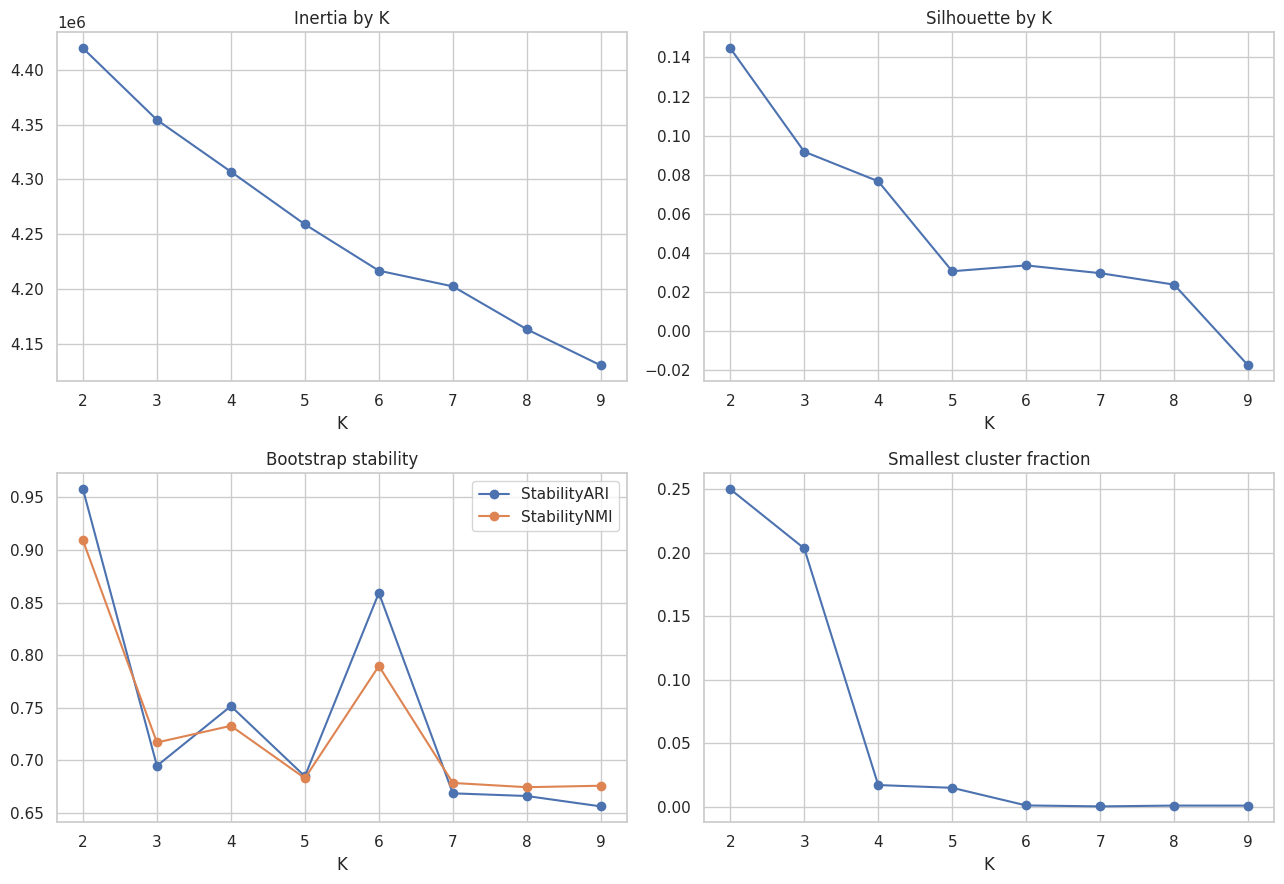

Selected K: 2
Selected solution status: accepted
Five- and six-cluster diagnostics:


,Silhouette,DBI,CHI,Clusters,NoiseFraction,MinClusterFraction,StabilityARI,StabilityNMI,Inertia
K,,,,,,,,,
5,0.030400,4.387292,406.492794,5,0.0,0.014887,0.684827,0.683042,4.259017e+06
6,0.033389,3.975277,381.876904,6,0.0,0.001012,0.859164,0.789680,4.216761e+06


K=5: REJECTED AS PRIMARY SOLUTION
K=6: REJECTED AS PRIMARY SOLUTION


In [11]:
rng = np.random.default_rng(RANDOM_STATE)
k_rows = []

for k in K_VALUES:
    reference = KMeans(n_clusters=k, n_init=20, random_state=RANDOM_STATE)
    reference_labels = reference.fit_predict(X_discovery_pca)
    row = {'K': k, **clustering_metrics(X_discovery_pca, reference_labels)}

    stability_runs = []
    sample_n = int(len(X_discovery_pca) * STABILITY_SAMPLE_FRACTION)
    for repeat in range(STABILITY_REPEATS):
        sample_idx = rng.choice(len(X_discovery_pca), size=sample_n, replace=True)
        model = KMeans(
            n_clusters=k,
            n_init=20,
            random_state=RANDOM_STATE + repeat + 1,
        )
        model.fit(X_discovery_pca[sample_idx])
        stability_runs.append(model.predict(X_discovery_pca))

    row['StabilityARI'], row['StabilityNMI'] = mean_pairwise_agreement(stability_runs)
    row['Inertia'] = reference.inertia_
    k_rows.append(row)

k_results = pd.DataFrame(k_rows).set_index('K')
display(k_results)

fig, axes = plt.subplots(2, 2, figsize=(13, 9))
k_results['Inertia'].plot(marker='o', ax=axes[0, 0], title='Inertia by K')
k_results['Silhouette'].plot(marker='o', ax=axes[0, 1], title='Silhouette by K')
k_results[['StabilityARI', 'StabilityNMI']].plot(marker='o', ax=axes[1, 0], title='Bootstrap stability')
k_results['MinClusterFraction'].plot(marker='o', ax=axes[1, 1], title='Smallest cluster fraction')
plt.tight_layout()
plt.show()

eligible_k = k_results[
    (k_results['MinClusterFraction'] >= 0.03) &
    (k_results['StabilityARI'] >= 0.80)
]
selection_passed_gates = not eligible_k.empty
if eligible_k.empty:
    print('No K met both conservative thresholds; selecting the highest ARI/silhouette rank.')
    ranked = k_results.assign(
        combined_rank=k_results['StabilityARI'].rank(ascending=False) + k_results['Silhouette'].rank(ascending=False)
    )
    selected_k = int(ranked['combined_rank'].idxmin())
else:
    selected_k = int(eligible_k['Silhouette'].idxmax())

selected_solution_status = 'accepted' if selection_passed_gates else 'exploratory_fallback'
print('Selected K:', selected_k)
print('Selected solution status:', selected_solution_status)
if not selection_passed_gates:
    print('Do not describe or operationalise this solution as a validated learner taxonomy.')
print('Five- and six-cluster diagnostics:')
interpret_diagnostics = k_results.loc[[k for k in INTERPRET_K_VALUES if k in k_results.index]]
display(interpret_diagnostics)
for interpret_k, row in interpret_diagnostics.iterrows():
    accepted = (
        row['Silhouette'] >= 0.10 and
        row['StabilityARI'] >= 0.80 and
        row['MinClusterFraction'] >= 0.03
    )
    decision = 'ACCEPTED FOR FURTHER VALIDATION' if accepted else 'REJECTED AS PRIMARY SOLUTION'
    print(f'K={interpret_k}: {decision}')

## Fit the selected K-Means model

In [12]:
kmeans = KMeans(n_clusters=selected_k, n_init=50, random_state=RANDOM_STATE)
discovery_labels = kmeans.fit_predict(X_discovery_pca)
validation_labels = kmeans.predict(X_validation_pca)

cluster_labels = pd.Series(index=profiles.index, dtype='float64', name='cluster')
cluster_labels.loc[discovery_users] = discovery_labels
cluster_labels.loc[validation_users] = validation_labels
cluster_labels = cluster_labels.astype(int)

print('Discovery metrics:')
display(pd.Series(clustering_metrics(X_discovery_pca, discovery_labels)))
print('Validation assignment metrics:')
display(pd.Series(clustering_metrics(X_validation_pca, validation_labels)))
display(cluster_labels.value_counts().sort_index().rename('learners'))

Discovery metrics:


,0
Silhouette,0.144771
DBI,4.715064
CHI,597.705099
Clusters,2.000000
NoiseFraction,0.000000
MinClusterFraction,0.250037


Validation assignment metrics:


,0
Silhouette,0.160905
DBI,4.807590
CHI,144.126991
Clusters,2.000000
NoiseFraction,0.000000
MinClusterFraction,0.241488


,learners
cluster,
0,25057
1,8278


## Algorithm comparison on one common sample


In [13]:
compare_rng = np.random.default_rng(RANDOM_STATE)
compare_n = min(ALGORITHM_SAMPLE_SIZE, len(X_discovery_pca))
comparison_rows = []
comparison_samples = []

for repeat in range(ALGORITHM_REPEATS):
    compare_idx = compare_rng.choice(len(X_discovery_pca), size=compare_n, replace=False)
    X_compare = X_discovery_pca[compare_idx]
    comparison_samples.append(X_compare)
    repeated_labels = {
        'KMeans': KMeans(
            n_clusters=selected_k, n_init=30, random_state=RANDOM_STATE + repeat
        ).fit_predict(X_compare),
        'Hierarchical': AgglomerativeClustering(
            n_clusters=selected_k, linkage='ward'
        ).fit_predict(X_compare),
        'GMM-diagonal': GaussianMixture(
            n_components=selected_k,
            covariance_type='diag',
            reg_covar=1e-5,
            random_state=RANDOM_STATE + repeat,
        ).fit_predict(X_compare),
    }
    for model_name, labels in repeated_labels.items():
        comparison_rows.append({
            'Repeat': repeat,
            'Model': model_name,
            **clustering_metrics(X_compare, labels),
        })

algorithm_results = pd.DataFrame(comparison_rows)
algorithm_summary = algorithm_results.groupby('Model').agg(
    SilhouetteMean=('Silhouette', 'mean'),
    SilhouetteStd=('Silhouette', 'std'),
    DBIMean=('DBI', 'mean'),
    CHIMean=('CHI', 'mean'),
    MinClusterFractionMean=('MinClusterFraction', 'mean'),
    MinClusterFractionMinimum=('MinClusterFraction', 'min'),
).sort_values('SilhouetteMean', ascending=False)
display(algorithm_results)
display(algorithm_summary)

# Tune DBSCAN on the first reproducible comparison sample. Noise is excluded
# from cohesion/separation metrics and reported separately.
X_compare = comparison_samples[0]
min_samples_grid = [10, 20]
dbscan_candidates = []
for min_samples in min_samples_grid:
    neighbours = NearestNeighbors(n_neighbors=min_samples).fit(X_compare)
    distances, _ = neighbours.kneighbors(X_compare)
    kth_distances = distances[:, -1]
    for quantile in [0.70, 0.80, 0.90, 0.95]:
        eps = float(np.quantile(kth_distances, quantile))
        labels = DBSCAN(eps=eps, min_samples=min_samples).fit_predict(X_compare)
        metrics = clustering_metrics(X_compare, labels, ignore_noise=True)
        dbscan_candidates.append({
            'eps': eps, 'min_samples': min_samples, 'labels': labels, **metrics,
        })

dbscan_grid = pd.DataFrame([
    {key: value for key, value in row.items() if key != 'labels'}
    for row in dbscan_candidates
]).sort_values(['Silhouette', 'NoiseFraction'], ascending=[False, True])
display(dbscan_grid)
valid_dbscan = [
    row for row in dbscan_candidates
    if np.isfinite(row['Silhouette']) and row['Clusters'] >= 2 and row['NoiseFraction'] <= 0.50
]
if valid_dbscan:
    best_dbscan = max(valid_dbscan, key=lambda row: row['Silhouette'])
    display(pd.Series({key: value for key, value in best_dbscan.items() if key != 'labels'}, name='Best DBSCAN'))
else:
    print('No DBSCAN candidate produced at least two clusters with <=50% noise.')

,Repeat,Model,Silhouette,DBI,CHI,Clusters,NoiseFraction,MinClusterFraction
0,0,KMeans,0.154909,4.613541,115.659432,2,0.0,0.2354
1,0,Hierarchical,0.139093,5.836872,75.299419,2,0.0,0.2440
2,0,GMM-diagonal,0.081012,7.302633,42.257028,2,0.0,0.4146
3,1,KMeans,0.152312,4.797479,108.307612,2,0.0,0.2416
4,1,Hierarchical,0.093230,6.270958,66.545533,2,0.0,0.2926
5,1,GMM-diagonal,0.070172,7.176735,41.747823,2,0.0,0.4034
6,2,KMeans,0.173779,4.631269,113.574240,2,0.0,0.2304
7,2,Hierarchical,0.148555,5.844681,71.902003,2,0.0,0.2334
8,2,GMM-diagonal,0.077020,7.180397,41.638515,2,0.0,0.4108
9,3,KMeans,0.158452,4.730486,114.583145,2,0.0,0.2504


,SilhouetteMean,SilhouetteStd,DBIMean,CHIMean,MinClusterFractionMean,MinClusterFractionMinimum
Model,,,,,,
KMeans,0.158872,0.008615,4.664507,113.886473,0.23760,0.2302
Hierarchical,0.122581,0.022145,5.960084,71.622991,0.25704,0.2334
GMM-diagonal,0.076874,0.004031,7.143906,43.165228,0.41060,0.4034


,eps,min_samples,Silhouette,DBI,CHI,Clusters,NoiseFraction,MinClusterFraction
7,26.517612,20,NaN,NaN,NaN,1,0.0284,NaN
3,25.497920,10,NaN,NaN,NaN,1,0.0324,NaN
6,21.081351,20,NaN,NaN,NaN,1,0.0656,NaN
2,20.552087,10,NaN,NaN,NaN,1,0.0696,NaN
5,14.740905,20,NaN,NaN,NaN,1,0.1490,NaN
1,14.241290,10,NaN,NaN,NaN,1,0.1568,NaN
4,11.218607,20,NaN,NaN,NaN,1,0.2412,NaN
0,10.824708,10,NaN,NaN,NaN,1,0.2512,NaN


No DBSCAN candidate produced at least two clusters with <=50% noise.


## PCA and exposure-ablation comparisons


In [14]:
non_pca_labels = KMeans(
    n_clusters=selected_k, n_init=30, random_state=RANDOM_STATE
).fit_predict(X_discovery_scaled)
pca_comparison = pd.DataFrame([
    {'Space': 'PCA', **clustering_metrics(X_discovery_pca, discovery_labels)},
    {'Space': 'Full scaled', **clustering_metrics(X_discovery_scaled, non_pca_labels)},
])
display(pca_comparison)

ablation_rows = []
ablation_labels = {}
for feature_set_name, columns in feature_sets.items():
    local_imputer = SimpleImputer(strategy='median')
    local_scaler = StandardScaler()
    local_pca = PCA(n_components=PCA_VARIANCE, random_state=RANDOM_STATE)
    local_x = local_imputer.fit_transform(profiles.loc[discovery_users, columns])
    local_x = local_scaler.fit_transform(local_x)
    if local_x.shape[1] > 1:
        local_x = local_pca.fit_transform(local_x)
    local_labels = KMeans(
        n_clusters=selected_k, n_init=30, random_state=RANDOM_STATE
    ).fit_predict(local_x)
    ablation_labels[feature_set_name] = local_labels
    ablation_rows.append({
        'FeatureSet': feature_set_name,
        'InputFeatures': len(columns),
        'OutputDimensions': local_x.shape[1],
        **clustering_metrics(local_x, local_labels),
    })

ablation_results = pd.DataFrame(ablation_rows).set_index('FeatureSet')
ablation_agreement = pd.DataFrame([
    {
        'FeatureSet': name,
        'ARIWithExposureOnly': adjusted_rand_score(labels, ablation_labels['exposure_only']),
    }
    for name, labels in ablation_labels.items()
    if name != 'exposure_only'
])
display(ablation_results)
display(ablation_agreement)

,Space,Silhouette,DBI,CHI,Clusters,NoiseFraction,MinClusterFraction
0,PCA,0.144771,4.715064,597.705099,2,0.0,0.250037
1,Full scaled,0.139952,4.867590,569.085496,2,0.0,0.249513


,InputFeatures,OutputDimensions,Silhouette,DBI,CHI,Clusters,NoiseFraction,MinClusterFraction
FeatureSet,,,,,,,,
behaviour_mastery,182,159,0.131974,4.761520,610.701290,2,0.0,0.258100
behaviour_mastery_no_affect,178,156,0.144771,4.715064,597.705099,2,0.0,0.250037
combined_with_exposure,187,161,0.233084,5.052204,611.600182,2,0.0,0.219252
exposure_only,5,3,0.515681,0.797199,21816.708547,2,0.0,0.217302


,FeatureSet,ARIWithExposureOnly
0,behaviour_mastery,-0.003676
1,behaviour_mastery_no_affect,0.006936
2,combined_with_exposure,0.358942


## Cluster profiles, including five and six clusters


In [15]:
profile_view_cols = exposure_cols + [
    'success_rate', 'avg_response_time_log', 'avg_hints', 'avg_attempts',
    'bottom_hint_rate', 'skill_coverage_rate', 'avg_frustrated',
    'avg_confused', 'avg_concentrating', 'avg_bored',
] + first_action_cols

selected_profiles = profiles[profile_view_cols].join(cluster_labels)
selected_profile_means = selected_profiles.groupby('cluster').mean()
selected_profile_means.insert(0, 'learners', cluster_labels.value_counts().sort_index())
display(selected_profile_means)

for interpret_k in INTERPRET_K_VALUES:
    interpret_model = KMeans(
        n_clusters=interpret_k, n_init=50, random_state=RANDOM_STATE
    ).fit(X_discovery_pca)
    labels_all = pd.Series(index=profiles.index, dtype='float64')
    labels_all.loc[discovery_users] = interpret_model.labels_
    labels_all.loc[validation_users] = interpret_model.predict(X_validation_pca)
    labels_all = labels_all.astype(int).rename('cluster')
    table = profiles[profile_view_cols].join(labels_all).groupby('cluster').mean()
    table.insert(0, 'learners', labels_all.value_counts().sort_index())
    print(f'Profiles for K={interpret_k}')
    display(table)

,learners,log_interactions,log_active_days,interactions_per_active_day,observed_supported_skills,mean_mastery_confidence,success_rate,avg_response_time_log,avg_hints,avg_attempts,bottom_hint_rate,skill_coverage_rate,avg_frustrated,avg_confused,avg_concentrating,avg_bored,first_action_0_rate,first_action_1_rate,first_action_2_rate
cluster,,,,,,,,,,,,,,,,,,,
0,25057,4.210896,1.786254,17.599353,7.596799,0.021367,0.725206,10.147476,0.161070,1.279634,0.054585,0.109105,0.391027,0.044591,0.596985,0.245291,0.974158,0.020864,0.004978
1,8278,4.343923,1.806729,19.812239,7.917251,0.021577,0.466855,10.181864,0.943905,1.633826,0.297337,0.103983,0.387233,0.037310,0.544697,0.294115,0.816883,0.173355,0.009762


Profiles for K=5


,learners,log_interactions,log_active_days,interactions_per_active_day,observed_supported_skills,mean_mastery_confidence,success_rate,avg_response_time_log,avg_hints,avg_attempts,bottom_hint_rate,skill_coverage_rate,avg_frustrated,avg_confused,avg_concentrating,avg_bored,first_action_0_rate,first_action_1_rate,first_action_2_rate
cluster,,,,,,,,,,,,,,,,,,,
0,497,5.409402,2.642702,18.836871,27.682093,0.063947,0.517780,9.747047,0.294046,1.396255,0.150697,0.146367,0.383452,0.051050,0.651701,0.276272,0.918577,0.066896,0.014527
1,5934,4.227778,1.678548,20.625063,5.716549,0.016409,0.432247,10.209821,1.135443,1.670280,0.347158,0.090959,0.387774,0.034252,0.528891,0.301017,0.776202,0.215389,0.008408
2,12251,4.018529,1.796826,14.036548,9.698392,0.026244,0.723174,10.441168,0.255343,1.368888,0.080023,0.177273,0.387494,0.041895,0.547681,0.282531,0.962859,0.031255,0.005886
3,1460,5.829923,3.165808,17.848139,31.452740,0.100142,0.809459,10.279919,0.202563,1.216278,0.065261,0.110395,0.387282,0.045792,0.693667,0.277777,0.980291,0.016787,0.002922
4,13193,4.241084,1.652796,20.861186,3.295384,0.008878,0.695248,9.868718,0.116864,1.245903,0.046920,0.049206,0.394089,0.046799,0.627828,0.211518,0.976420,0.018118,0.005462


Profiles for K=6


,learners,log_interactions,log_active_days,interactions_per_active_day,observed_supported_skills,mean_mastery_confidence,success_rate,avg_response_time_log,avg_hints,avg_attempts,bottom_hint_rate,skill_coverage_rate,avg_frustrated,avg_confused,avg_concentrating,avg_bored,first_action_0_rate,first_action_1_rate,first_action_2_rate
cluster,,,,,,,,,,,,,,,,,,,
0,13296,4.239922,1.653358,20.820833,3.318066,0.008973,0.694650,9.873255,0.118109,1.247696,0.047359,0.049666,0.394036,0.046692,0.627396,0.211817,0.976233,0.018271,0.005496
1,12222,4.027111,1.803448,14.056117,9.797333,0.026568,0.724336,10.439719,0.255151,1.367729,0.080031,0.177233,0.387519,0.041964,0.548247,0.282740,0.962945,0.031201,0.005854
2,5911,4.223833,1.676174,20.611288,5.692099,0.016291,0.431671,10.210202,1.138588,1.670989,0.347737,0.091202,0.387768,0.034191,0.528339,0.301181,0.775620,0.215999,0.008382
3,34,5.798425,3.344324,12.607382,30.000000,0.084289,0.680159,10.113297,0.246823,1.290041,0.084409,0.168906,0.382995,0.035423,0.676799,0.278114,0.972082,0.020091,0.007827
4,1371,5.838266,3.170416,17.974933,31.746171,0.101336,0.811271,10.287970,0.202257,1.214207,0.065123,0.109687,0.387199,0.045991,0.694469,0.278030,0.980491,0.016734,0.002774
5,501,5.408336,2.637260,18.881127,27.628743,0.063669,0.519409,9.741674,0.289165,1.391405,0.147978,0.145524,0.383503,0.052081,0.652671,0.275564,0.919241,0.066158,0.014601


## Temporal external validation


In [16]:
early_outcomes = early.groupby('user_id').agg(
    early_success_rate=('correct', 'mean'),
)
later_outcomes = later.groupby('user_id').agg(
    future_success_rate=('correct', 'mean'),
    future_avg_hints=('hint_count', 'mean'),
    future_avg_attempts=('attempt_count', 'mean'),
    future_bottom_hint_rate=('bottom_hint', 'mean'),
    future_interactions=('correct', 'size'),
    future_first_time=('event_time', 'min'),
    future_last_time=('event_time', 'max'),
)
later_outcomes['future_active_span_days'] = (
    later_outcomes['future_last_time'] - later_outcomes['future_first_time']
).dt.total_seconds() / 86400
later_outcomes['learning_gain'] = (
    later_outcomes['future_success_rate'] - early_outcomes['early_success_rate']
)

validation_frame = later_outcomes.join(cluster_labels, how='inner')
outcome_cols = [
    'future_success_rate', 'future_avg_hints', 'future_avg_attempts',
    'future_bottom_hint_rate', 'future_active_span_days', 'learning_gain',
]

display(validation_frame.groupby('cluster')[outcome_cols].agg(['mean', 'median', 'count']))

test_rows = []
for outcome in outcome_cols:
    groups = [
        group[outcome].dropna().to_numpy()
        for _, group in validation_frame.groupby('cluster')
        if group[outcome].notna().sum() >= 2
    ]
    if len(groups) >= 2:
        statistic, p_value = kruskal(*groups)
        total_n = sum(len(group) for group in groups)
        epsilon_squared = max(0.0, (statistic - len(groups) + 1) / (total_n - len(groups)))
    else:
        statistic, p_value, epsilon_squared = np.nan, np.nan, np.nan
    test_rows.append({
        'Outcome': outcome,
        'KruskalH': statistic,
        'PValue': p_value,
        'EpsilonSquared': epsilon_squared,
    })

temporal_tests = pd.DataFrame(test_rows)
finite_mask = temporal_tests['PValue'].notna()
finite_p = temporal_tests.loc[finite_mask, 'PValue'].to_numpy()
order = np.argsort(finite_p)
holm_sorted = np.maximum.accumulate((len(finite_p) - np.arange(len(finite_p))) * finite_p[order])
holm_adjusted = np.empty_like(finite_p)
holm_adjusted[order] = np.clip(holm_sorted, 0, 1)
temporal_tests.loc[finite_mask, 'HolmAdjustedPValue'] = holm_adjusted
temporal_tests = temporal_tests.sort_values('PValue')
display(temporal_tests)

future_success_rate                  future_avg_hints            \
                       mean    median  count             mean    median   
cluster                                                                   
0                  0.704831  0.731429  25057         0.227859  0.066667   
1                  0.497343  0.514546   8278         0.890295  0.706152   

               future_avg_attempts                  future_bottom_hint_rate  \
         count                mean    median  count                    mean   
cluster                                                                       
0        25057            1.305681  1.218182  25057                0.079662   
1         8278            1.544303  1.466667   8278                0.291595   

                         future_active_span_days                    \
           median  count                    mean     median  count   
cluster                                                              
0        0.015293  25014               36.890831  10.022731  25057   
1        0.240000   8259               32.201591   6.721678   8278   

        learning_gain                   
                 mean    median  count  
cluster                                 
0           -0.020375 -0.009259  25057  
1            0.030489  0.025772   8278

,Outcome,KruskalH,PValue,EpsilonSquared,HolmAdjustedPValue
0,future_success_rate,5681.827670,0.000000e+00,0.170427,0.000000e+00
1,future_avg_hints,8089.427276,0.000000e+00,0.242655,0.000000e+00
2,future_avg_attempts,3449.055263,0.000000e+00,0.103443,0.000000e+00
3,future_bottom_hint_rate,7858.291535,0.000000e+00,0.236160,0.000000e+00
5,learning_gain,455.697886,4.150640e-101,0.013641,8.301280e-101
4,future_active_span_days,4.758570,2.915275e-02,0.000113,2.915275e-02


## Does cluster membership improve future-success prediction?


In [17]:
discovery_future = later_outcomes.loc[discovery_users, 'future_success_rate']
validation_future = later_outcomes.loc[validation_users, 'future_success_rate']
truth = validation_future.to_numpy()

cluster_future_means = pd.DataFrame({
    'cluster': discovery_labels,
    'future_success_rate': discovery_future.to_numpy(),
}).groupby('cluster')['future_success_rate'].mean()
global_prediction = np.repeat(discovery_future.mean(), len(validation_users))
cluster_prediction = pd.Series(validation_labels).map(cluster_future_means).to_numpy()

# Stronger baseline 1: carry the learner's early success rate forward.
early_success_discovery = early_outcomes.loc[discovery_users, ['early_success_rate']]
early_success_validation = early_outcomes.loc[validation_users, ['early_success_rate']]
early_success_prediction = early_success_validation['early_success_rate'].to_numpy()

# Stronger baseline 2: calibrate early success using discovery learners only.
calibration_model = LinearRegression()
calibration_model.fit(early_success_discovery, discovery_future)
calibrated_success_prediction = calibration_model.predict(early_success_validation)

# Incremental-value test: compare the same nonlinear behavioural model without
# and with one-hot cluster membership.
predictive_cols = behaviour_without_affect_cols + exposure_cols
predictive_train = profiles.loc[discovery_users, predictive_cols].copy()
predictive_valid = profiles.loc[validation_users, predictive_cols].copy()
predictive_train_with_cluster = predictive_train.copy()
predictive_valid_with_cluster = predictive_valid.copy()
cluster_indicator_cols = []
for cluster_id in range(selected_k):
    column = f'cluster_{cluster_id}'
    cluster_indicator_cols.append(column)
    predictive_train_with_cluster[column] = (discovery_labels == cluster_id).astype(int)
    predictive_valid_with_cluster[column] = (validation_labels == cluster_id).astype(int)

def make_future_model():
    return Pipeline([
        ('imputer', SimpleImputer(strategy='median')),
        ('model', HistGradientBoostingRegressor(
            max_iter=200,
            learning_rate=0.05,
            max_leaf_nodes=31,
            l2_regularization=1.0,
            random_state=RANDOM_STATE,
        )),
    ])

behaviour_model = make_future_model()
behaviour_cluster_model = make_future_model()
behaviour_model.fit(predictive_train, discovery_future)
behaviour_cluster_model.fit(predictive_train_with_cluster, discovery_future)
behaviour_prediction = behaviour_model.predict(predictive_valid)
behaviour_cluster_prediction = behaviour_cluster_model.predict(predictive_valid_with_cluster)

predictions = {
    'Global mean': global_prediction,
    'Cluster only': cluster_prediction,
    'Early success carried forward': early_success_prediction,
    'Calibrated early success': calibrated_success_prediction,
    'Behaviour model': behaviour_prediction,
    'Behaviour model + cluster': behaviour_cluster_prediction,
}
prediction_results = pd.DataFrame([
    {'Model': name, 'MAE': mean_absolute_error(truth, prediction)}
    for name, prediction in predictions.items()
]).sort_values('MAE')
display(prediction_results)

# Paired bootstrap confidence interval for the incremental value of adding
# cluster membership to an otherwise identical behavioural model.
bootstrap_rng = np.random.default_rng(RANDOM_STATE)
incremental_improvements = []
for _ in range(2_000):
    idx = bootstrap_rng.integers(0, len(truth), size=len(truth))
    incremental_improvements.append(
        mean_absolute_error(truth[idx], behaviour_prediction[idx]) -
        mean_absolute_error(truth[idx], behaviour_cluster_prediction[idx])
    )
incremental_ci = np.quantile(incremental_improvements, [0.025, 0.975])
incremental_test = pd.DataFrame([{
    'MeanMAEImprovement': float(np.mean(incremental_improvements)),
    'CI95Lower': float(incremental_ci[0]),
    'CI95Upper': float(incremental_ci[1]),
    'ReliablePositiveImprovement': bool(incremental_ci[0] > 0),
    'BootstrapRepeats': len(incremental_improvements),
}])
display(incremental_test)
if not incremental_test['ReliablePositiveImprovement'].iloc[0]:
    print('Cluster membership has not demonstrated reliable incremental predictive value.')

,Model,MAE
5,Behaviour model + cluster,0.117404
4,Behaviour model,0.117702
3,Calibrated early success,0.123478
2,Early success carried forward,0.124499
1,Cluster only,0.151932
0,Global mean,0.169462


,MeanMAEImprovement,CI95Lower,CI95Upper,ReliablePositiveImprovement,BootstrapRepeats
0,0.000294,0.00001,0.000568,True,2000


## Optional supervised feature ranking

In [18]:
if RUN_SUPERVISED_IMPORTANCE:
    supervised_features = behaviour_cols + exposure_cols + mastery_cols
    supervised_train_x = profiles.loc[discovery_users, supervised_features]
    supervised_train_y = later_outcomes.loc[discovery_users, 'future_success_rate']
    supervised_valid_x = profiles.loc[validation_users, supervised_features]
    supervised_valid_y = later_outcomes.loc[validation_users, 'future_success_rate']

    supervised_model = Pipeline([
        ('imputer', SimpleImputer(strategy='median')),
        ('model', HistGradientBoostingRegressor(
            max_iter=200,
            learning_rate=0.05,
            max_leaf_nodes=31,
            l2_regularization=1.0,
            random_state=RANDOM_STATE,
        )),
    ])
    supervised_model.fit(supervised_train_x, supervised_train_y)
    supervised_prediction = supervised_model.predict(supervised_valid_x)
    print('Supervised validation MAE:', mean_absolute_error(supervised_valid_y, supervised_prediction))

    importance_n = min(5_000, len(supervised_valid_x))
    importance_sample = supervised_valid_x.sample(importance_n, random_state=RANDOM_STATE)
    importance_target = supervised_valid_y.loc[importance_sample.index]
    importance = permutation_importance(
        supervised_model,
        importance_sample,
        importance_target,
        scoring='neg_mean_absolute_error',
        n_repeats=3,
        random_state=RANDOM_STATE,
        n_jobs=-1,
    )
    feature_importance = pd.DataFrame({
        'Feature': supervised_features,
        'ImportanceMean': importance.importances_mean,
        'ImportanceStd': importance.importances_std,
    }).sort_values('ImportanceMean', ascending=False)
    display(feature_importance.head(30))
else:
    print('Supervised feature ranking skipped. Set RUN_SUPERVISED_IMPORTANCE=True to run it.')

Supervised validation MAE: 0.11652741742475341


,Feature,ImportanceMean,ImportanceStd
0,success_rate,0.063347,0.000764
5,skill_coverage_rate,0.001294,0.000191
10,avg_log_position,0.001191,0.000067
12,avg_attempts,0.001034,0.000073
21,log_interactions,0.000988,0.000038
25,mean_mastery_confidence,0.000978,0.000144
3,assistment_coverage_rate,0.000948,0.000073
13,bottom_hint_rate,0.000732,0.000063
7,median_response_time_log,0.000722,0.000217
15,first_action_1_rate,0.000511,0.000011


## PCA and optional UMAP visualisation


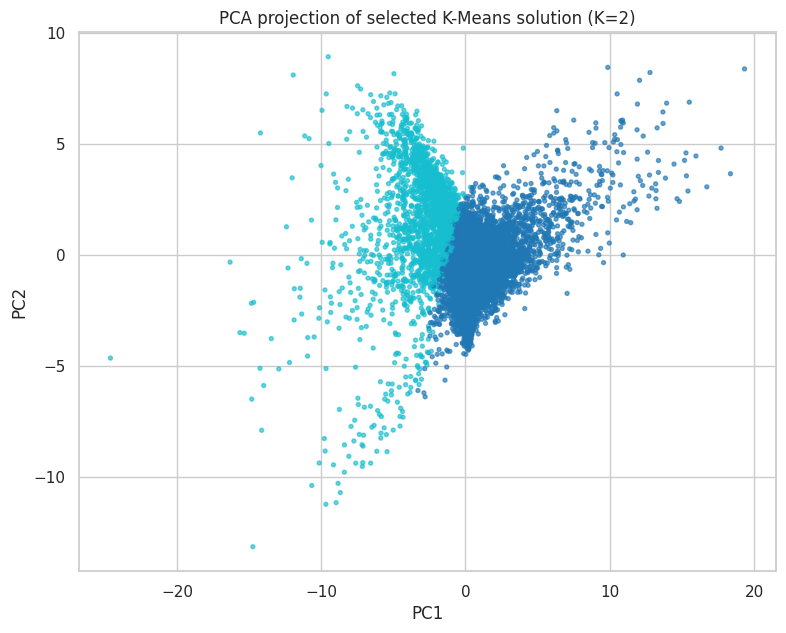

In [19]:
plot_n = min(10_000, len(X_discovery_pca))
plot_rng = np.random.default_rng(RANDOM_STATE)
plot_idx = plot_rng.choice(len(X_discovery_pca), size=plot_n, replace=False)

if X_discovery_pca.shape[1] >= 2:
    plt.figure(figsize=(9, 7))
    plt.scatter(
        X_discovery_pca[plot_idx, 0],
        X_discovery_pca[plot_idx, 1],
        c=discovery_labels[plot_idx],
        s=8,
        alpha=0.65,
        cmap='tab10',
    )
    plt.xlabel('PC1')
    plt.ylabel('PC2')
    plt.title(f'PCA projection of selected K-Means solution (K={selected_k})')
    plt.show()

if RUN_UMAP:
    try:
        import umap.umap_ as umap
        reducer = umap.UMAP(n_neighbors=30, min_dist=0.1, random_state=RANDOM_STATE)
        embedding = reducer.fit_transform(X_discovery_pca[plot_idx])
        plt.figure(figsize=(9, 7))
        plt.scatter(
            embedding[:, 0], embedding[:, 1],
            c=discovery_labels[plot_idx], s=8, alpha=0.65, cmap='tab10'
        )
        plt.title(f'UMAP projection of selected solution (K={selected_k})')
        plt.show()
    except ImportError:
        print('UMAP is not installed. Run !pip install umap-learn or set RUN_UMAP=False.')

## Save reproducible outputs


In [20]:
artifact_bundle = {
    'imputer': imputer,
    'scaler': scaler,
    'pca': pca,
    'kmeans': kmeans,
    'feature_columns': feature_cols,
    'selected_k': selected_k,
    'selected_solution_status': selected_solution_status,
    'main_feature_set': MAIN_FEATURE_SET,
    'skill_priors': skill_priors,
    'kept_skills': list(kept_skills),
    'mastery_prior_strength': MASTERY_PRIOR_STRENGTH,
    'random_state': RANDOM_STATE,
}
joblib.dump(artifact_bundle, OUTPUT_DIR / 'assistments_clustering_bundle.joblib')

assignments = profiles[profile_view_cols].join(cluster_labels)
assignments.to_csv(OUTPUT_DIR / 'learner_cluster_assignments.csv')
k_results.to_csv(OUTPUT_DIR / 'k_selection_results.csv')
algorithm_results.to_csv(OUTPUT_DIR / 'algorithm_comparison_repeats.csv', index=False)
algorithm_summary.to_csv(OUTPUT_DIR / 'algorithm_comparison_summary.csv')
pca_comparison.to_csv(OUTPUT_DIR / 'pca_comparison.csv', index=False)
ablation_results.to_csv(OUTPUT_DIR / 'feature_ablation_results.csv')
ablation_agreement.to_csv(OUTPUT_DIR / 'feature_ablation_agreement.csv', index=False)
temporal_tests.to_csv(OUTPUT_DIR / 'temporal_validation_tests.csv', index=False)
prediction_results.to_csv(OUTPUT_DIR / 'future_success_prediction_baselines.csv', index=False)
incremental_test.to_csv(OUTPUT_DIR / 'incremental_cluster_test.csv', index=False)
selected_profile_means.to_csv(OUTPUT_DIR / 'selected_cluster_profiles.csv')
if RUN_SUPERVISED_IMPORTANCE:
    feature_importance.to_csv(OUTPUT_DIR / 'future_success_feature_importance.csv', index=False)

run_config = {
    'data_path': DATA_PATH,
    'row_limit': ROW_LIMIT,
    'minimum_interactions': MIN_INTERACTIONS,
    'early_fraction': EARLY_FRACTION,
    'minimum_skill_learners': MIN_SKILL_LEARNERS,
    'pca_variance': PCA_VARIANCE,
    'algorithm_repeats': ALGORITHM_REPEATS,
    'first_action_categories': FIRST_ACTION_CATEGORIES,
    'unknown_skill_mastery_excluded': True,
    'selected_k': selected_k,
    'selected_solution_status': selected_solution_status,
    'selection_passed_gates': bool(selection_passed_gates),
    'main_feature_set': MAIN_FEATURE_SET,
}
with open(OUTPUT_DIR / 'run_config.json', 'w') as file:
    json.dump(run_config, file, indent=2)

# Reopen the saved artifacts instead of relying only on successful write calls.
reloaded_bundle = joblib.load(OUTPUT_DIR / 'assistments_clustering_bundle.joblib')
assert reloaded_bundle['selected_k'] == selected_k
assert reloaded_bundle['feature_columns'] == feature_cols
assert len(reloaded_bundle['kmeans'].predict(X_validation_pca[:10])) == min(10, len(X_validation_pca))
reloaded_assignments = pd.read_csv(OUTPUT_DIR / 'learner_cluster_assignments.csv')
assert len(reloaded_assignments) == len(profiles)
with open(OUTPUT_DIR / 'run_config.json') as file:
    reloaded_config = json.load(file)
assert reloaded_config['selected_k'] == selected_k

print('Saved outputs to:', OUTPUT_DIR)
saved_files = sorted(path for path in OUTPUT_DIR.iterdir() if path.is_file())
print('\n'.join(f'{path.name}: {path.stat().st_size:,} bytes' for path in saved_files))
if (OUTPUT_DIR / 'algorithm_comparison_sample.csv').exists():
    print('Warning: algorithm_comparison_sample.csv is from an older run; use the repeated and summary files instead.')
print('Artifact reload verification passed.')

Saved outputs to: /content/drive/MyDrive/datasets/assistments_final_outputs
algorithm_comparison_repeats.csv: 1,306 bytes
algorithm_comparison_summary.csv: 444 bytes
assistments_clustering_bundle.joblib: 358,197 bytes
feature_ablation_agreement.csv: 163 bytes
feature_ablation_results.csv: 539 bytes
future_success_feature_importance.csv: 10,779 bytes
future_success_prediction_baselines.csv: 249 bytes
incremental_cluster_test.csv: 161 bytes
k_selection_results.csv: 1,236 bytes
learner_cluster_assignments.csv: 9,130,137 bytes
pca_comparison.csv: 247 bytes
run_config.json: 501 bytes
selected_cluster_profiles.csv: 1,049 bytes
temporal_validation_tests.csv: 530 bytes
Artifact reload verification passed.
